In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.warp import transform

In [5]:
eq = pd.read_csv("D:\Download\HW3_data\HW3_data\Earthquakes.csv")
eq.head()

,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16-08-2023 12:47,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19-07-2023 00:22,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17-07-2023 03:05,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16-07-2023 06:48,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16-07-2023 06:48,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN


In [8]:
eq.info()
eq.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      1000 non-null   object 
 1   magnitude  1000 non-null   float64
 2   date_time  1000 non-null   object 
 3   cdi        1000 non-null   int64  
 4   mmi        1000 non-null   int64  
 5   alert      449 non-null    object 
 6   tsunami    1000 non-null   int64  
 7   sig        1000 non-null   int64  
 8   net        1000 non-null   object 
 9   nst        1000 non-null   int64  
 10  dmin       1000 non-null   float64
 11  gap        1000 non-null   float64
 12  magType    1000 non-null   object 
 13  depth      1000 non-null   float64
 14  latitude   1000 non-null   float64
 15  longitude  1000 non-null   float64
 16  location   994 non-null    object 
 17  continent  284 non-null    object 
 18  country    651 non-null    object 
dtypes: float64(6), int64(5), object(8)
memory usage: 

Index(['title', 'magnitude', 'date_time', 'cdi', 'mmi', 'alert', 'tsunami',
       'sig', 'net', 'nst', 'dmin', 'gap', 'magType', 'depth', 'latitude',
       'longitude', 'location', 'continent', 'country'],
      dtype='object')

### Question 1

In [10]:
eq["mag_prefix"] = eq["title"].str.extract(r"^(M)")
eq["location_raw"] = eq["title"].str.split(" - ", n=1).str[1]
eq["pure_location"] = eq["location_raw"].str.replace(r"^\d+\s+km\s+[A-Z]+\s+of\s+","",regex=True)
eq[["title", "mag_prefix", "pure_location"]].head()

,title,mag_prefix,pure_location
0,"M 6.5 - 42 km W of Sola, Vanuatu",M,"Sola, Vanuatu"
1,"M 6.5 - 43 km S of Intipucá, El Salvador",M,"Intipucá, El Salvador"
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",M,"Loncopué, Argentina"
3,"M 7.2 - 98 km S of Sand Point, Alaska",M,"Sand Point, Alaska"
4,M 7.3 - Alaska Peninsula,M,Alaska Peninsula


In [11]:
missing_percent = eq[["continent", "country"]].isna().mean() * 100
missing_percent

continent    71.6
country      34.9
dtype: float64

In [16]:
eq["country"] = eq["country"].str.strip().str.upper()
eq[["country"]].head()

,country
0,VANUATU
1,NaN
2,ARGENTINA
3,NaN
4,NaN


我先從欄位"title"中取出地震規模前綴，並建立欄位"mag_prefix"  
接著，我整理地點文字，移除距離和方向，並建立欄位"pure_location"
另外，計算"continent"和"country"欄位的缺失值比例
最後，我把欄位"country"前後空白去除，並轉成大寫

### Question 2

In [17]:
eq["date_time"] = pd.to_datetime(eq["date_time"])
eq = eq.set_index("date_time")
eq = eq.sort_index()
eq.head()

C:\Users\RCH\AppData\Local\Temp\ipykernel_4756\3226136386.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  eq["date_time"] = pd.to_datetime(eq["date_time"])


,title,magnitude,cdi,mmi,alert,tsunami,sig,net,nst,dmin,...,magType,depth,latitude,longitude,location,continent,country,mag_prefix,location_raw,pure_location
date_time,,,,,,,,,,,,,,,,,,,,,
1995-05-05 03:53:00,"M 7.1 - 14 km NE of Cabatuan, Philippines",7.1,0,7,NaN,0,776,us,0,0.0,...,mw,16.0,12.626,125.297,"Cabatuan, Philippines",NaN,PHILIPPINES,M,"14 km NE of Cabatuan, Philippines","Cabatuan, Philippines"
1995-05-13 08:47:00,"M 6.6 - 10 km W of Aianí, Greece",6.6,0,9,NaN,0,670,us,0,0.0,...,mw,14.0,40.149,21.695,"Aianí, Greece",Europe,GREECE,M,"10 km W of Aianí, Greece","Aianí, Greece"
1995-05-14 11:33:00,"M 6.9 - 27 km NNW of Maubara, Timor Leste",6.9,0,6,NaN,0,732,us,0,0.0,...,mw,11.2,-8.378,125.127,"Maubara, Timor Leste",NaN,INDONESIA,M,"27 km NNW of Maubara, Timor Leste","Maubara, Timor Leste"
1995-05-16 20:12:00,"M 7.7 - 249 km E of Vao, New Caledonia",7.7,0,4,NaN,0,912,us,0,0.0,...,mw,20.2,-23.008,169.900,"Vao, New Caledonia",NaN,NaN,M,"249 km E of Vao, New Caledonia","Vao, New Caledonia"
1995-05-27 13:03:00,"M 7.1 - 85 km S of Tungor, Russia",7.1,0,9,NaN,0,776,us,0,0.0,...,mwb,11.0,52.629,142.827,"Tungor, Russia",Asia,RUSSIA,M,"85 km S of Tungor, Russia","Tungor, Russia"


In [19]:
major_eq = eq[eq["magnitude"] >= 7.0]
major_eq.head()

,title,magnitude,cdi,mmi,alert,tsunami,sig,net,nst,dmin,...,magType,depth,latitude,longitude,location,continent,country,mag_prefix,location_raw,pure_location
date_time,,,,,,,,,,,,,,,,,,,,,
1995-05-05 03:53:00,"M 7.1 - 14 km NE of Cabatuan, Philippines",7.1,0,7,NaN,0,776,us,0,0.0,...,mw,16.0,12.626,125.297,"Cabatuan, Philippines",NaN,PHILIPPINES,M,"14 km NE of Cabatuan, Philippines","Cabatuan, Philippines"
1995-05-16 20:12:00,"M 7.7 - 249 km E of Vao, New Caledonia",7.7,0,4,NaN,0,912,us,0,0.0,...,mw,20.2,-23.008,169.900,"Vao, New Caledonia",NaN,NaN,M,"249 km E of Vao, New Caledonia","Vao, New Caledonia"
1995-05-27 13:03:00,"M 7.1 - 85 km S of Tungor, Russia",7.1,0,9,NaN,0,776,us,0,0.0,...,mwb,11.0,52.629,142.827,"Tungor, Russia",Asia,RUSSIA,M,"85 km S of Tungor, Russia","Tungor, Russia"
1995-07-30 05:11:00,"M 8.0 - 36 km NNE of Antofagasta, Chile",8.0,0,8,NaN,0,985,us,0,0.0,...,mw,45.6,-23.340,-70.294,Ant,South America,CHILE,M,"36 km NNE of Antofagasta, Chile","Antofagasta, Chile"
1995-08-16 10:27:00,"M 7.7 - 155 km WNW of Panguna, Papua New Guinea",7.7,0,6,NaN,0,912,us,0,0.0,...,mw,30.1,-5.799,154.178,"Panguna, Papua New Guinea",NaN,NaN,M,"155 km WNW of Panguna, Papua New Guinea","Panguna, Papua New Guinea"


In [20]:
yearly_stats = major_eq.resample("Y").agg(total_major_earthquakes=("magnitude", "count"),average_depth=("depth", "mean"))
yearly_stats

C:\Users\RCH\AppData\Local\Temp\ipykernel_4756\4173146291.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_stats = major_eq.resample("Y").agg(total_major_earthquakes=("magnitude", "count"),average_depth=("depth", "mean"))


,total_major_earthquakes,average_depth
date_time,,
1995-12-31,14,43.492857
1996-12-31,12,76.691667
1997-12-31,13,66.046154
1998-12-31,8,43.737500
1999-12-31,16,59.114375
2000-12-31,11,61.490909
2001-12-31,12,38.500000
2002-12-31,9,50.366667
2003-12-31,11,26.363636


In [21]:
yearly_stats.index = yearly_stats.index.year
yearly_stats

,total_major_earthquakes,average_depth
date_time,,
1995,14,43.492857
1996,12,76.691667
1997,13,66.046154
1998,8,43.737500
1999,16,59.114375
2000,11,61.490909
2001,12,38.500000
2002,9,50.366667
2003,11,26.363636


In [22]:
continent_stats = major_eq.groupby("continent").agg(total_major_earthquakes=("magnitude", "count"),average_depth=("depth", "mean"))
continent_stats

,total_major_earthquakes,average_depth
continent,,
Africa,1,11.000000
Asia,45,43.058822
Europe,1,21.000000
North America,28,33.254643
Oceania,3,236.333333
South America,28,152.865714


我先將欄位"date_time"轉換成時間格式，並把它設為資料表的index
接著，依照時間順序排序資料
之後，篩選出規模大於或等於 7.0 的大地震
最後，再依年份和洲別計算大地震數量與平均深度

### Question 3

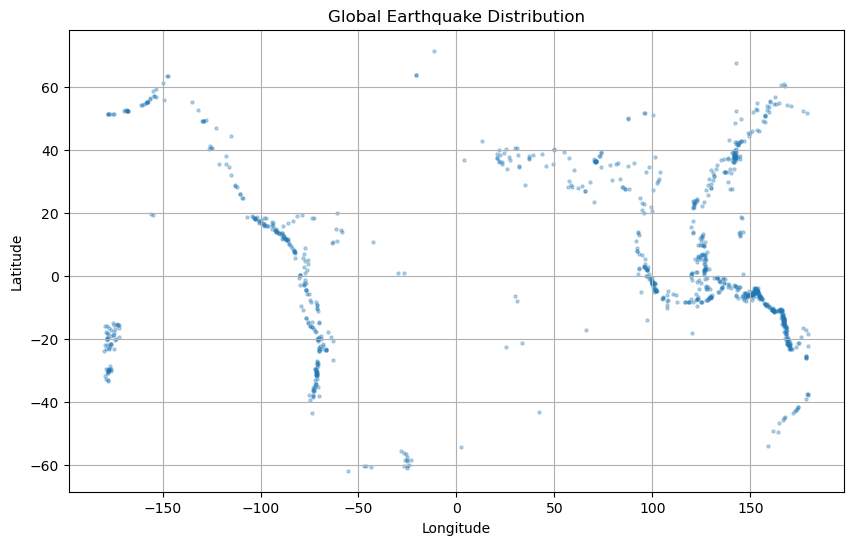

In [23]:
plt.figure(figsize=(10, 6))

plt.scatter(eq["longitude"],eq["latitude"],s=5,alpha=0.3)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Global Earthquake Distribution")
plt.grid(True)

plt.show()

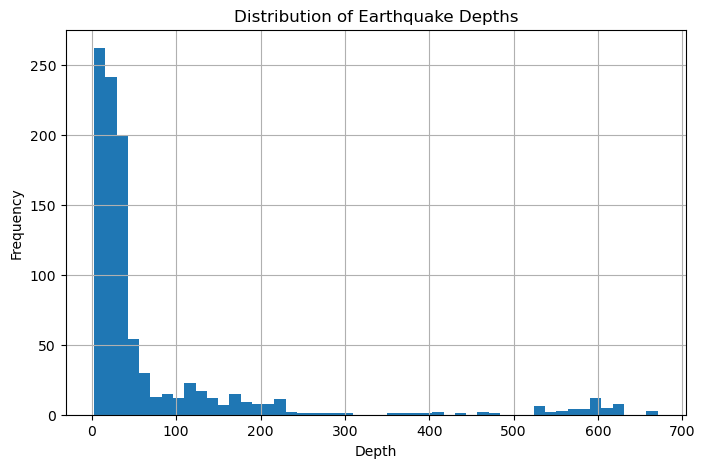

In [24]:
plt.figure(figsize=(8, 5))
plt.hist(eq["depth"],bins=50)

plt.xlabel("Depth")
plt.ylabel("Frequency")
plt.title("Distribution of Earthquake Depths")
plt.grid(True)

plt.show()

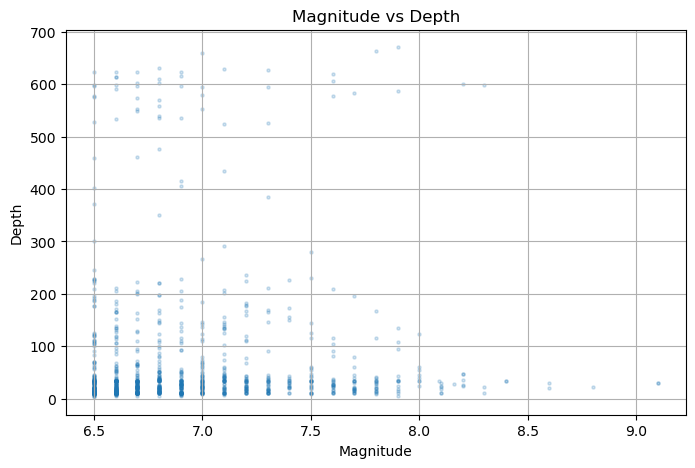

In [25]:
plt.figure(figsize=(8, 5))
plt.scatter(eq["magnitude"],eq["depth"],s=5,alpha=0.2)

plt.xlabel("Magnitude")
plt.ylabel("Depth")
plt.title("Magnitude vs Depth")
plt.grid(True)

plt.show()

第一張圖用經度和緯度畫出全球地震分布
第二張圖用直方圖呈現地震深度的分布  
第三張圖比較地震規模和深度的關係

### Question 4

In [37]:
dem = rasterio.open("D:/Download/HW3_data/HW3_data/dem.tif")

print("Metadata:")
print(dem.meta)

print("\nSpatial Resolution:")
print(dem.res)

print("\nCoordinate Reference System:")
print(dem.crs)

Metadata:
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -32767.0, 'width': 10035, 'height': 18852, 'count': 1, 'crs': CRS.from_wkt('PROJCS["TWD97 / TM2 zone 121",GEOGCS["TWD97",DATUM["Taiwan_Datum_1997",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1026"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","3824"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",121],PARAMETER["scale_factor",0.9999],PARAMETER["false_easting",250000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","3826"]]'), 'transform': Affine(19.99999999962072, 0.0, 150969.99999970233,
       0.0, -19.99999999962072, 2799169.999916302)}

Spatial Resolution:
(19.99999999962072, 19.99999999962072)

Coordinate Reference System:
EPSG:3826


In [38]:
dem_matrix = dem.read(1)
dem_matrix.shape

(18852, 10035)

In [39]:
left, bottom, right, top = dem.bounds

lon_bounds, lat_bounds = transform(dem.crs,"EPSG:4326",[left, right],[bottom, top])

min_lon, max_lon = min(lon_bounds), max(lon_bounds)
min_lat, max_lat = min(lat_bounds), max(lat_bounds)

print("Longitude range:", min_lon, "to", max_lon)
print("Latitude range:", min_lat, "to", max_lat)

Longitude range: 120.04163169146258 to 122.00964772674067
Latitude range: 21.894001858644597 to 25.298017420027904


In [40]:
inside_dem = ((eq["longitude"] >= min_lon) &(eq["longitude"] <= max_lon) &(eq["latitude"] >= min_lat) &(eq["latitude"] <= max_lat))

eq_inside = eq[inside_dem].copy()

print("Number of earthquakes inside DEM extent:", len(eq_inside))

eq_inside[["longitude", "latitude", "magnitude", "depth"]].head()

Number of earthquakes inside DEM extent: 8


,longitude,latitude,magnitude,depth
date_time,,,,
1996-09-05 23:42:00,121.498,21.898,6.8,20.0
1999-09-20 17:47:00,120.982,23.772,7.7,33.0
1999-09-25 23:52:00,121.158,23.738,6.5,17.0
2003-12-10 04:38:00,121.362,23.039,6.8,10.0
2006-12-26 12:34:00,120.493,21.974,6.9,10.0


In [41]:
src_crs = "EPSG:4326"
dst_crs = dem.crs

xs, ys = transform(src_crs,dst_crs,eq_inside["longitude"].values,eq_inside["latitude"].values)

list(zip(xs[:5], ys[:5]))

[(301456.5685507952, 2422347.2124203886),
 (248165.43916699427, 2629773.2668730374),
 (266107.56366395147, 2626016.8081249613),
 (287098.9493085944, 2548647.5863430616),
 (197641.29328582296, 2430765.0871068332)]

In [42]:
rows, cols = rasterio.transform.rowcol(dem.transform,xs,ys)

eq_inside["row"] = rows
eq_inside["col"] = cols

eq_inside[["longitude", "latitude", "row", "col"]].head()

,longitude,latitude,row,col
date_time,,,,
1996-09-05 23:42:00,121.498,21.898,18841,7524
1999-09-20 17:47:00,120.982,23.772,8469,4859
1999-09-25 23:52:00,121.158,23.738,8657,5756
2003-12-10 04:38:00,121.362,23.039,12526,6806
2006-12-26 12:34:00,120.493,21.974,18420,2333


In [43]:
valid = ((eq_inside["row"] >= 0) &(eq_inside["row"] < dem_matrix.shape[0]) &(eq_inside["col"] >= 0) &(eq_inside["col"] < dem_matrix.shape[1]))

print("Number of valid points:", valid.sum())
print("Number of invalid points:", (~valid).sum())

Number of valid points: 8
Number of invalid points: 0


In [44]:
eq_inside["elevation"] = np.nan

eq_inside.loc[valid, "elevation"] = dem_matrix[eq_inside.loc[valid, "row"].astype(int),eq_inside.loc[valid, "col"].astype(int)]

eq_inside[["longitude", "latitude", "magnitude", "depth", "row", "col", "elevation"]].head()

,longitude,latitude,magnitude,depth,row,col,elevation
date_time,,,,,,,
1996-09-05 23:42:00,121.498,21.898,6.8,20.0,18841,7524,-32767.000000
1999-09-20 17:47:00,120.982,23.772,7.7,33.0,8469,4859,1309.410034
1999-09-25 23:52:00,121.158,23.738,6.5,17.0,8657,5756,1786.520020
2003-12-10 04:38:00,121.362,23.039,6.8,10.0,12526,6806,-32767.000000
2006-12-26 12:34:00,120.493,21.974,6.9,10.0,18420,2333,-32767.000000


In [45]:
eq["elevation"] = np.nan

eq.loc[eq_inside.index, "elevation"] = eq_inside["elevation"]

eq[eq["elevation"].notna()][["longitude", "latitude", "magnitude", "depth", "elevation"]].head()

,longitude,latitude,magnitude,depth,elevation
date_time,,,,,
1996-09-05 23:42:00,121.498,21.898,6.8,20.0,-32767.000000
1999-09-20 17:47:00,120.982,23.772,7.7,33.0,1309.410034
1999-09-25 23:52:00,121.158,23.738,6.5,17.0,1786.520020
2003-12-10 04:38:00,121.362,23.039,6.8,10.0,-32767.000000
2006-12-26 12:34:00,120.493,21.974,6.9,10.0,-32767.000000


我先開啟"dem.tif"，並印出它的基本資料、解析度和座標系統 
接著，我讀取DEM的高程矩陣
因為地震資料是全球資料，但DEM只包含台灣附近，所以我先用DEM的範圍篩選出台灣附近的地震
接著，我將地震的經緯度轉換成 DEM 的座標系統，再轉成DEM矩陣中的row和col
最後，用row和col從DEM矩陣中取出高程，並新增成"elevation"

### Question 5

In [46]:
left, bottom, right, top = dem.bounds

lon_bounds, lat_bounds = transform(dem.crs,"EPSG:4326",[left, right],[bottom, top])

min_lon, max_lon = min(lon_bounds), max(lon_bounds)
min_lat, max_lat = min(lat_bounds), max(lat_bounds)

print("Longitude range:", min_lon, "to", max_lon)
print("Latitude range:", min_lat, "to", max_lat)

Longitude range: 120.04163169146258 to 122.00964772674067
Latitude range: 21.894001858644597 to 25.298017420027904


In [47]:
taiwan_eq = eq[(eq["longitude"] >= min_lon) &(eq["longitude"] <= max_lon) &(eq["latitude"] >= min_lat) &(eq["latitude"] <= max_lat)].copy()

print("Number of earthquakes in Taiwan DEM extent:", len(taiwan_eq))

taiwan_eq[["longitude", "latitude", "magnitude", "depth"]].head()

Number of earthquakes in Taiwan DEM extent: 8


,longitude,latitude,magnitude,depth
date_time,,,,
1996-09-05 23:42:00,121.498,21.898,6.8,20.0
1999-09-20 17:47:00,120.982,23.772,7.7,33.0
1999-09-25 23:52:00,121.158,23.738,6.5,17.0
2003-12-10 04:38:00,121.362,23.039,6.8,10.0
2006-12-26 12:34:00,120.493,21.974,6.9,10.0


In [48]:
regular_eq = taiwan_eq[taiwan_eq["magnitude"] <= 6]
major_taiwan_eq = taiwan_eq[taiwan_eq["magnitude"] > 6]

print("Regular earthquakes:", len(regular_eq))
print("Major earthquakes:", len(major_taiwan_eq))

Regular earthquakes: 0
Major earthquakes: 8


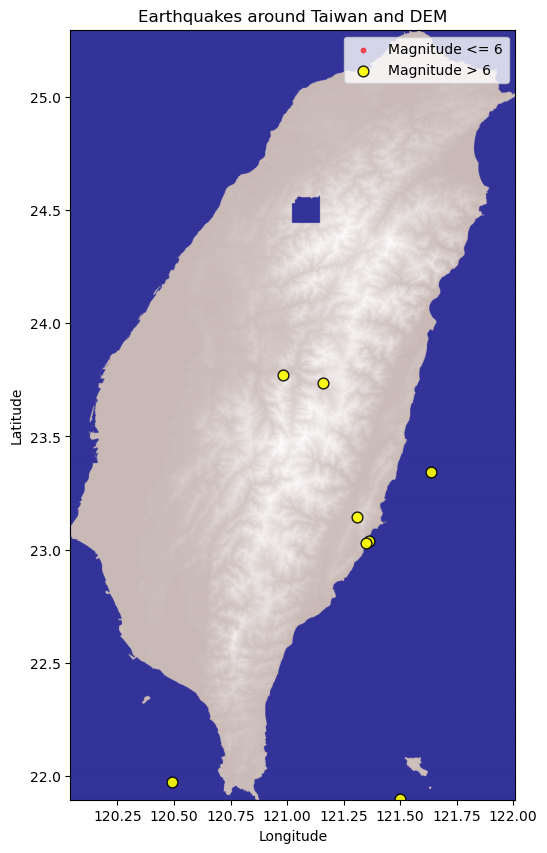

In [49]:
plt.figure(figsize=(8, 10))

plt.imshow(dem_matrix[::5, ::5],cmap="terrain",extent=[min_lon, max_lon, min_lat, max_lat],origin="upper")

plt.scatter(regular_eq["longitude"],regular_eq["latitude"],s=10,c="red",alpha=0.6,label="Magnitude <= 6")

plt.scatter(major_taiwan_eq["longitude"],major_taiwan_eq["latitude"],s=60,c="yellow",edgecolors="black",alpha=0.9,label="Magnitude > 6")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Earthquakes around Taiwan and DEM")
plt.legend()
plt.show()

我先用DEM的空間範圍篩選出台灣附近的地震，排除其他地區的地震  
接著，把DEM畫成背景圖，並把地震點疊加在地形圖上
規模小於或等於6的地震用紅色小點表示，規模大於6的地震用黃色大點表示

Disclaimer: AI was only partially referenced for logic suggestions; the final implementation and code details were independently modified and completed by myself.